**A brief overview of <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span>**:

<span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span> is a open-source, light-weight code for **X-ray spectral shifting and stacking**. 

Given the **redshift** of each spectrum in a list, <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span> will first shift these spectra *(PHA, counts vs. output energy (channel))* from observed-frame to rest-frame, and then sum them together. The response matrix files *(RMF, the probability that a photon with input energy $E_1$ will be detected with an output energy $E_2$)* and ancillary response files *(ARF, effective area vs. input energy)* are shifted and stacked in a similar way to the spectrum. <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span> also supports correction of Galactic absorption, if an additional **NH** value (in units of 1 $\text{cm}^{-2}$) for each spectrum is given.

In this demo, a preliminary example is provided (stacking powerlaws) to help you get started with <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span>. Running <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span> is very easy: you simply need to specify where the spectral files are stored, along with the redshift and Galactic absorption (if possible). After that, you can run <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span> in one go.

In [1]:
# the main module
from Xstack.Xstack import XstackRunner
from Xstack.config import default_nh_file

# some miscellaneous packages for plotting, and generating fake spectra
from Xstack.simu.simulate_spec import make_fkspec
from Xstack.utils.pi import make_grpflg
from Xstack.visual.view import make_dataarf_plot,valid_energy_range_plot

# the usual packages
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits
from tqdm import tqdm
import os

# **1. Primary example: stacking single powerlaws**
***with different redshift, photon indices, and luminosities***

I have already generated 200 powerlaws with different redshifts ($0.3<z<2.0$), rest-frame 0.5-10 keV luminosities ($44.5<\log L_\text{0.5-10}<45.5$) and photon indices ($1.9<\Gamma<2.1$), based on the ARF, RMF, and background information of an arbitary *eROSITA* observation (eFEDS ID: 00007). These spectral files are stored in `./data/po/po_spec`. The redshift of each source is recorded as `./data/po/po_spec/{srcid}_po.pi.z`

Now let us walk through the basic procedures of running <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span>.

## **Step 1**: Initialize <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span>

You will first tell <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span> where your spectral files are stored. The block below fetches some basic data.

In [2]:
# fetch some basic data (they have already been generated)
pifile_lst = []
bkgpifile_lst = []
rmffile_lst = []
arffile_lst = []
z_lst = []

for i in range(200):
    pifile = f"./data/po/po_spec/{i:05d}_po.pi"
    with fits.open(pifile) as hdu:
        head = hdu[1].header
    path = os.path.dirname(pifile)
    bkgpifile = os.path.join(path,head["BACKFILE"])
    rmffile = os.path.join(path,head["RESPFILE"])
    arffile = os.path.join(path,head["ANCRFILE"])
    zfile = os.path.join(path,head["ZFILE"])        # file storing redshift
    with open(zfile,"r") as f:
        z = f.readlines()
    z = float(z[0].rstrip())

    pifile_lst.append(pifile)
    bkgpifile_lst.append(bkgpifile)
    rmffile_lst.append(rmffile)
    arffile_lst.append(arffile)
    z_lst.append(z)

Initialize <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span> as follows:

In [3]:
data_po = XstackRunner(
    pifile_lst=pifile_lst,                          # PI file list
    arffile_lst=arffile_lst,                        # ARF file list
    rmffile_lst=rmffile_lst,                        # RMF file list
    z_lst=z_lst,                                    # redshift list
    bkgpifile_lst=bkgpifile_lst,                    # bkg PI file list
    srcid_lst=np.arange(200),                       # source ID list (can be arbitary)
    rspwt_method="SHP",                             # method to calculate response weighting factor for each source (recommended: SHP)
    rspproj_gamma=2.0,                              # prior photon index for projecting RSP matrix onto the output energy channel
    int_rng=(1.0,2.3),                              # if `arfscal_method`=`SHP`, choose the range to calculate flux
    sample_rmf=None,                                # the sample RMF to read input/output energy bin edge (if not specified, the first RMF in `rmffile_lst` will be used)
    sample_arf=None,                                # the sample ARF to read input/output energy bin edge (if not specified, the first RMF in `rmffile_lst` will be used)
    Nbkggrp=10,                                     # the number of background groups to calculate uncertainty of background
    ene_trc=0.2,                                    # energy below which the ARF is manually truncated (e.g., 0.2 keV for eROSITA)
    nthreads=10,                                    # number of cpus used for RMF shifting
    prefix="./data/po/po_",							# prefix for all output files
)

**Some notes:**

The X-ray spectrum (PHA, counts vs. output energy (channel)) we observe is the convolution result of the intrinsic model and instrument response. The basic formula that connects these quantities together is:

$$
\begin{align}
\lambda_i=\sum_j R_{ij}\times A_{j}\times F_{j}\times \Delta t\times \Delta E_{j}
\end{align}
$$

where:
* $\lambda_i$ is the expected photon counts in some output energy channel $i$ (or $E_{i}$). In units of **$\text{counts}$**.
* $R_{ij}$ is the probability that a photon with input energy $E_{j}$ end up in the output energy channel $i$ (or $E_{i}$). Defined by RMF. **Unitless**.
* $A_{j}$ is the effective area for photons with input energy $E_{j}$. Defined by ARF. In units of **$\text{cm}^2$**.
* $F_{j}$ is the model for the source. In units of **$\text{counts}\ \text{s}^{-1}\ \text{cm}^{-2}\ \text{keV}^{-1}$**.
* $\Delta t$ is exposure time. In units of **$\text{s}$**.
* $\Delta E_{j}$ is the input energy width (usually defined by `ENERG_LO` and `ENERG_HI` in `SPECRESP` extension of ARF or `MATRIX` extension of RMF, as per OGIP standards). In units of **$\text{keV}$**.

If the photon counts are sufficiently large, we can safely infer the underlying physical model from observed spectrum and response, by spectral fitting. However, low-counts X-ray spectra are rather common in astronomical context, especially in the coming era of *eROSITA*. Although fitting individual spectrum is unreliable under this scenario, it is possible to infer the *averaged* physical model from the stacked spectrum of many sources, whose signal-to-noise ratio should be comparable to those high-counts spectra. The stacked spectrum can be formally written as:

$$
\begin{align}
\lambda_i^\text{stack}=\sum_j R_{ij}^\text{stack}\times A_{j}^\text{stack}\times F_{j}\times \Delta t^\text{stack}\times \Delta E_{j}
\end{align}
$$

where $R_{ij}^\text{stack}$ and $A_{j}^\text{stack}$ are the stacked RMF and stacked ARF, respectively. $F_{j}$ is the averaged model for the spectra to be stacked. $\Delta t^\text{stack}$ is the stacked exposure and can generally be taken as $\Delta t^\text{stack}=\Delta t^1+\Delta t^2+...+\Delta t^N$, where the superscript $1,2,...,N$ denotes the spectrum ID. The key of X-ray spectral stacking is to find $\lambda_i^\text{stack}$, $R_{ij}^\text{stack}$ and $A_{j}^\text{stack}$.

To achieve as high SNR as possible, <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span> sums the rest-frame photon counts of each source directly, without scaling them to a common flux level (which is the common technique of optical spectra stacking). This means that in the output energy channel $i$:

$$
\begin{align}
\lambda_i^\text{stack}=\lambda_i^1+...+\lambda_i^N&=\sum_j R_{ij}^1\times A_{j}^1\times F_{j}^1\times \Delta t^1\times \Delta E_{j}\\
&+...\\
&+\sum_j R_{ij}^N\times A_{j}^N\times F_{j}^N\times \Delta t^N\times \Delta E_{j}\\
\end{align}
$$

where $\lambda_i^{1,2,...,N}$ are now the **rest-frame** photon counts. 

To obtain $R_{ij}^\text{stack}$ and $A_{j}^\text{stack}$, some prior assumption on the physical models $F_{j}^{1,2,...,N}$ should be made:
1. **All sources have same spectral shape and same flux**: $F_{j}^{1}=F_{j}^{2}=...=F_{j}^{N}=F_{j}$. To first order approximation, $R_{ij}^\text{stack}$ and $A_{j}^\text{stack}$ can be written as:

$$
\begin{align}
A_{j}^\text{stack}&\approx\frac{\Delta t^1}{\Delta t^\text{stack}}\cdot A_{j}^1+...+\frac{\Delta t^N}{\Delta t^\text{stack}}\cdot A_{j}^N\\
R_{ij}^\text{stack}&\approx\frac{\Delta t^1}{\Delta t^\text{stack}}\cdot R_{ij}^1+...+\frac{\Delta t^N}{\Delta t^\text{stack}}\cdot R_{ij}^N
\end{align}
$$

This ARF and RMF weighting method is specified as `FLX` (flux) in `arfscal_method`.

2. **All sources have same spectral shape and same luminosity**: $F_{j}^{1}\cdot 4\pi (d_L^1)^2=F_{j}^{2}\cdot 4\pi (d_L^2)^2=...=F_{j}^{N}\cdot 4\pi (d_L^N)^2=F_{j}\cdot 4\pi\times \text{1 Mpc}^2$. $d_L$ is luminosity distance. Similar to the `EXP` weighting method, $R_{ij}^\text{stack}$ and $A_{j}^\text{stack}$ can be written as:

$$
\begin{align}
A_{j}^\text{stack}&\approx\frac{\Delta t^1/(d_L^1)^2}{\Delta t^\text{stack}/(\text{1 Mpc})^2}\cdot A_{j}^1+...+\frac{\Delta t^N/(d_L^N)^2}{\Delta t^\text{stack}/(\text{1 Mpc})^2}\cdot A_{j}^N\\
R_{ij}^\text{stack}&\approx\frac{\Delta t^1/(d_L^1)^2}{\Delta t^\text{stack}/(\text{1 Mpc})^2}\cdot R_{ij}^1+...+\frac{\Delta t^N/(d_L^N)^2}{\Delta t^\text{stack}/(\text{1 Mpc})^2}\cdot R_{ij}^N
\end{align}
$$

This ARF and RMF weighting method is specified as `LMN` (luminosity) in `arfscal_method`.

3. **All sources have same spectral shape** (recommended): This should be the most unbiased weighting method among the three, as it takes the minimum assumption. Omitting the mathematical details, $R_{ij}^\text{stack}$ and $A_{j}^\text{stack}$ can be written as:

$$
\begin{align}
A_{j}^\text{stack}&\approx\frac{\sum_\text{1.0 keV}^\text{2.3 keV}\lambda_i^1}{\sum_\text{1.0 keV}^\text{2.3 keV}A_{j}^1\Delta E_{j}}\cdot A_{j}^1+...+\frac{\sum_\text{1.0 keV}^\text{2.3 keV}\lambda_i^N}{\sum_\text{1.0 keV}^\text{2.3 keV}A_{j}^N\Delta E_{j}}\cdot A_{j}^N\\
R_{ij}^\text{stack}&\approx\frac{\sum_\text{1.0 keV}^\text{2.3 keV}\lambda_i^1}{\sum_\text{1.0 keV}^\text{2.3 keV}A_{i}^1\Delta E_{j}}\cdot R_{ij}^1+...+\frac{\sum_\text{1.0 keV}^\text{2.3 keV}\lambda_i^N}{\sum_\text{1.0 keV}^\text{2.3 keV}A_{i}^N\Delta E_{j}}\cdot R_{ij}^N
\end{align}
$$

where `1.0 -- 2.3 keV` is the default integration range, and can be modified by `int_rng`.

This ARF and RMF weighting method is specified as `SHP` (shape) in `arfscal_method`.

## **Step 2**: Run <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span>

After initializing <span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span>, call the `run` method to get the stacked results.

The ARF weighting factor for each source, as well as the stacked RMF will be printed out when the stacking procedure is finished.

In [4]:
data_po.run()

stacking: 100%|██████████| 200/200 [00:00<00:00, 218.32it/s]


Finished. Please check ./data/po/po_runXstack.log for detailed log.


([array([ 0,  0,  0, ..., 16, 22, 10], shape=(1024,))],
 [array([0.        , 0.        , 0.        , ..., 4.        , 4.69041576,
         3.16227766], shape=(1024,))],
 [array([ 0.        ,  0.        ,  0.        , ..., 19.34457913,
         20.40252998, 10.34997636], shape=(1024,))],
 [array([0.        , 0.        , 0.        , ..., 0.68046363, 0.69917831,
         0.4984391 ], shape=(1024,))],
 [array([ 0.        ,  0.        ,  0.        , ..., 31.52543527,
         31.27987777, 13.32956301], shape=(1024,))],
 [array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.12274402, 0.11740567,
          0.05505484],
         [0.        , 0.        , 0.        , ..., 0.13739594, 0.14080724,

## **Step 3** (optional): Scientific analysis

### 1. Sanity check: determine a valid energy range for analysis

Not the entire energy range can be used for subsequent analysis. Two aspects need to be taken into account, when considering a specific rest-frame energy bin:

* **What fraction of sources are contributing at this energy?** If the completeness is too low (typically for low energy), we cannot use this energy. 
	- For example, if your sample contains a lot of high-redshift sources, you might expect that you need to start at a rest-frame higher energy.

* **What is the fraction of net counts at this energy?** If the background contribution is too high (fraction of net counts too low), the spectrum would be dominated by noise, and we cannot use this energy.
	- Since background is more prominent at higher energy, you might expect to truncate at some hard X-ray band.

There is a built-in function in Xstack to visualize these two (`valid_energy_range_plot`), see the example below. 

[Text(0.2, 0, '0.2'),
 Text(0.4, 0, '0.4'),
 Text(1.0, 0, '1.0'),
 Text(2.3, 0, '2.3'),
 Text(4.0, 0, '4.0'),
 Text(8.0, 0, '8.0')]

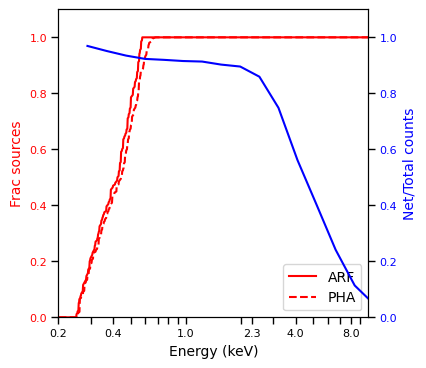

In [2]:
src_name = "./data/po/po_pi.fits"  		# source spectrum file
grp_name = "./data/po/po_grppi.fits"	# grouped source spectrum file to be created
bkg_name = "./data/po/po_bkgpi.fits"  	# background spectrum file
arf_name = "./data/po/po_arf.fits"  	# ARF file
rmf_name = "./data/po/po_rmf.fits"  	# RMF file
fene_name = "./data/po/po_fene.fits"  	# file storing the energy range of the source spectrum

fig, ax1 = plt.subplots(figsize=(4,4))
valid_energy_range_plot(fene_name,src_name,grp_name,bkg_name,rmf_name,ax=ax1)

ax1.set_xscale("log")
ax1.set_xlim(0.2,10)
x_ticks = [0.2, 0.4, 1.0, 2.3, 4.0, 8.0]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(x) for x in x_ticks])

Here you can see, `0.3 -- 8.0 keV` might be a good choice, where both fraction of sources contributing and fraction of net counts all exceed 20%.

### 2. Quick look of your stacked spectrum: ARF-weighted spectrum

To have a view on the spectral shape of the stacked spectrum, you can plot the ARF-weighted spectrum (i.e. stacked net photon counts divided by stacked ARF).

/data/chsj/software/installed/miniforge3/envs/henv/lib/python3.13/site-packages/Xstack/utils/rsp.py:1007: RuntimeWarning: invalid value encountered in divide
  grpspecresp.append((tmpspecresp * tmpwt / tmpwt.sum()).sum())
/data/chsj/software/installed/miniforge3/envs/henv/lib/python3.13/site-packages/Xstack/utils/rsp.py:1025: RuntimeWarning: invalid value encountered in divide
  grpspecresp.append((tmpspecresp * tmpwt / tmpwt.sum()).sum())


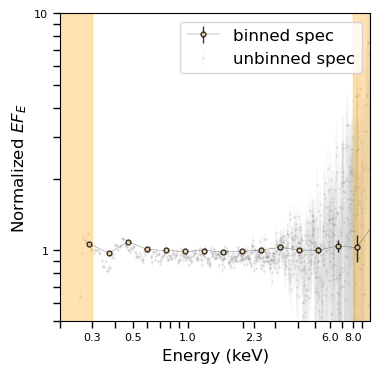

In [3]:
src_name = "./data/po/po_pi.fits"  		# source spectrum file
grp_name = "./data/po/po_grppi.fits"	# grouped source spectrum file to be created
bkg_name = "./data/po/po_bkgpi.fits"  	# background spectrum file
arf_name = "./data/po/po_arf.fits"  	# ARF file
rmf_name = "./data/po/po_rmf.fits"  	# RMF file

# create a grouped PI spectrum
with fits.open(rmf_name) as hdu:
    ebo = hdu["EBOUNDS"].data
ene_lo = ebo["E_MIN"]
ene_hi = ebo["E_MAX"]
ene_ce = (ene_lo + ene_hi) / 2
eene = np.logspace(np.log10(0.2),np.log10(ene_ce.max()),18)
eelo = eene[:-1]
eehi = eene[1:]
make_grpflg(
    src_name,   # source spectrum file
    grp_name,   # output grouped spectrum file
    method='EDGE',  # grouping spectrum by fixed edges, as specified in `eelo` and `eehi`
    rmf_fname=rmf_name,  # RMF file to be used for reading PI energy channels
    eelo=eelo,  # lower edges of the grouped energy channels
    eehi=eehi   # upper edges of the grouped energy channels
)

# make data/arf plot
fig, ax1 = plt.subplots(figsize=(4,4))
# for the grouped spectrum
make_dataarf_plot(
    src_name,
    bkg_name,
    arf_name,
    rmf_name,
    grp_name,
    normalize_at=4,	# normalize at 4 keV
    plot=True,
    ax=ax1,
    fmt="o-",ms=3.5,lw=0.20,c="k",capsize=0.,elinewidth=1.0,mec="k",mfc="#f9d7a7",alpha=0.8,zorder=1,label="binned spec"	# plotting kwargs
) # this plots EF(E), or equivalently leed in xspec; a powerlaw with photon index of 2 should look flat in this plot
# for the ungrouped spectrum
make_dataarf_plot(
    src_name,
    bkg_name,
    arf_name,
    rmf_name,
    normalize_at=4,	# normalize at 4 keV
    plot=True,
    ax=ax1,
    fmt="o",ms=0.3,lw=0.1,c="gray",alpha=0.5,zorder=-5,label="unbinned spec"
)

# below 0.3 keV: too few sources; above 8.0 keV: bkg dominated
ax1.fill_betweenx(y=[0.5,10], x1=0.2, x2=0.3, color="orange", alpha=0.3, zorder=-1) 
ax1.fill_betweenx(y=[0.5,10], x1=8.0, x2=10.0, color="orange", alpha=0.3, zorder=-1) 

ax1.legend(loc="upper right",fontsize=12)
ax1.set_xscale("log")
ax1.set_xlim(0.2,10)
x_ticks = [0.3, 0.5, 1.0, 2.3, 6.0, 8.0]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(x) for x in x_ticks])
ax1.set_xlabel("Energy (keV)",fontsize=12)
ax1.tick_params("x",which="major",
                length=10,width = 1.0,size=5,labelsize=8,pad=3)
ax1.tick_params("x",which="minor",
                length=10,width = 1.0,size=5,labelsize=8,pad=3)
ax1.set_ylim(0.5,10)
ax1.set_yscale("log")
y_ticks = [1,10]
ax1.set_yticks(y_ticks)
ax1.set_yticklabels([str(y) for y in y_ticks])
ax1.set_ylabel(r"Normalized $EF_E$",fontsize=12)
ax1.tick_params("y",which="major",
                length=10,width = 1.0,size=5,labelsize=8)
ax1.tick_params("y",which="minor",
                length=10,width = 1.0,size=5,labelsize=8)

**The output stacked spectrum closely resemble a $\Gamma=2$ power-law, which is what we want!**

### 3. XSPEC fitting

Check `./xspec_sh` for example scripts of spectral fitting with XSPEC.

# **2. Other examples**
***Try for yourself!***

## **e.g.2**: absorbed powerlaw

The Galactic absorption is often an issue when studying the X-ray spectra of extragalactic sources (e.g. AGNs), suppressing the soft X-ray flux significantly.

<span style="font-family: 'Courier New', Courier, monospace; font-weight: 700;">Xstack</span> allows for correction of Galactic absorption, in order to study the intrinsic spectral shape unaffected by the Galactic medium. This is essentially done by multiplying the observed-frame ARF (effective area vs. input energy) with Galactic absorption profile (absorption factor vs. input energy), as an approach to account for the expected loss of effective area due to the absorption effect. To activate this correction, you will need to specify the NH value of each spectrum (`nh_lst`), as well as the sample Galactic absorption profile (`nh_file`).

In [4]:
# fetch some basic data (they have already been generated)
pifile_lst = []
bkgpifile_lst = []
rmffile_lst = []
arffile_lst = []
z_lst = []
nh_lst = []

for i in range(200):
    pifile = f"./data/abspo/abspo_spec/{i:05d}_abspo.pi"
    with fits.open(pifile) as hdu:
        head = hdu[1].header
    path = os.path.dirname(pifile)
    bkgpifile = os.path.join(path,head["BACKFILE"])
    rmffile = os.path.join(path,head["RESPFILE"])
    arffile = os.path.join(path,head["ANCRFILE"])
    zfile = os.path.join(path,head["ZFILE"])        # file storing redshift
    nhfile = os.path.join(path,head["NHFILE"])        # file storing NH
    with open(zfile,"r") as f:
        z = f.readlines()
    z = float(z[0].rstrip())
    with open(nhfile,"r") as f:
        nh = f.readlines()
    nh = float(nh[0].rstrip())

    pifile_lst.append(pifile)
    bkgpifile_lst.append(bkgpifile)
    rmffile_lst.append(rmffile)
    arffile_lst.append(arffile)
    z_lst.append(z)
    nh_lst.append(nh)

# run Xstack
XstackRunner(
    pifile_lst=pifile_lst,                          # PI file list
    arffile_lst=arffile_lst,                        # ARF file list
    rmffile_lst=rmffile_lst,                        # RMF file list
    z_lst=z_lst,                                    # redshift list
    bkgpifile_lst=bkgpifile_lst,                    # bkg PI file list
    nh_lst=nh_lst,                                  # nh list
    srcid_lst=np.arange(200),                       # source ID list (can be arbitary)
    rspwt_method="SHP",                             # method to calculate response weighting factor for each source (recommended: SHP)
    rspproj_gamma=2.0,                              # prior photon index for projecting RSP matrix onto the output energy channel
    int_rng=(1.0,2.3),                              # if `arfscal_method`=`SHP`, choose the range to calculate flux
    sample_rmf=None,                                # the sample RMF to read input/output energy bin edge (if not specified, the first RMF in `rmffile_lst` will be used)
    sample_arf=None,                                # the sample ARF to read input/output energy bin edge (if not specified, the first RMF in `rmffile_lst` will be used)
    nh_file=default_nh_file,                 		# the Galactic absorption profile (absorption factor vs. energy)
    Nbkggrp=10,                                     # the number of background groups to calculate uncertainty of background
    ene_trc=0.2,                                    # energy below which the ARF is manually truncated (e.g., 0.2 keV for eROSITA)
    nthreads=30,                                    # number of cpus used for RMF shifting
    prefix="./data/abspo/abspo_",					# prefix for all output files
).run()

stacking: 100%|██████████| 200/200 [00:00<00:00, 408.88it/s]


Finished. Please check ./data/abspo/abspo_runXstack.log for detailed log.


([array([ 0,  0,  0, ..., 24, 18,  4], shape=(1024,))],
 [array([0.        , 0.        , 0.        , ..., 4.89897949, 4.24264069,
         2.        ], shape=(1024,))],
 [array([ 0.        ,  0.        ,  0.        , ..., 20.30676399,
         20.48576948, 10.1647332 ], shape=(1024,))],
 [array([0.        , 0.        , 0.        , ..., 0.69794628, 0.70040818,
         0.49323181], shape=(1024,))],
 [array([ 0.        ,  0.        ,  0.        , ..., 31.06613181,
         30.82239306, 13.00229002], shape=(1024,))],
 [array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.12308568, 0.11769228,
          0.05536498],
         [0.        , 0.        , 0.        , ..., 0.13780464, 0.14124225,

[Text(0.2, 0, '0.2'),
 Text(0.4, 0, '0.4'),
 Text(1.0, 0, '1.0'),
 Text(2.3, 0, '2.3'),
 Text(4.0, 0, '4.0'),
 Text(8.0, 0, '8.0')]

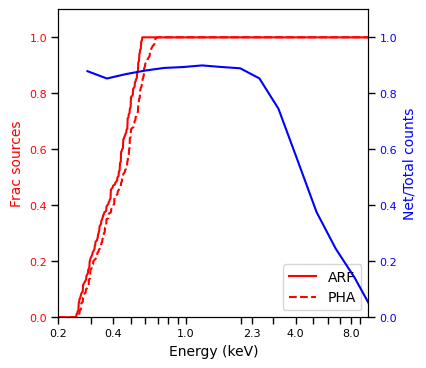

In [5]:
src_name = "./data/abspo/abspo_pi.fits"  		# source spectrum file
grp_name = "./data/abspo/abspo_grppi.fits"	# grouped source spectrum file to be created
bkg_name = "./data/abspo/abspo_bkgpi.fits"  	# background spectrum file
arf_name = "./data/abspo/abspo_arf.fits"  	# ARF file
rmf_name = "./data/abspo/abspo_rmf.fits"  	# RMF file
fene_name = "./data/abspo/abspo_fene.fits"  	# file storing the energy range of the source spectrum

fig, ax1 = plt.subplots(figsize=(4,4))
valid_energy_range_plot(fene_name,src_name,grp_name,bkg_name,rmf_name,ax=ax1)

ax1.set_xscale("log")
ax1.set_xlim(0.2,10)
x_ticks = [0.2, 0.4, 1.0, 2.3, 4.0, 8.0]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(x) for x in x_ticks])

/data/chsj/software/installed/miniforge3/envs/henv/lib/python3.13/site-packages/Xstack/utils/rsp.py:1007: RuntimeWarning: invalid value encountered in divide
  grpspecresp.append((tmpspecresp * tmpwt / tmpwt.sum()).sum())
/data/chsj/software/installed/miniforge3/envs/henv/lib/python3.13/site-packages/Xstack/utils/rsp.py:1025: RuntimeWarning: invalid value encountered in divide
  grpspecresp.append((tmpspecresp * tmpwt / tmpwt.sum()).sum())


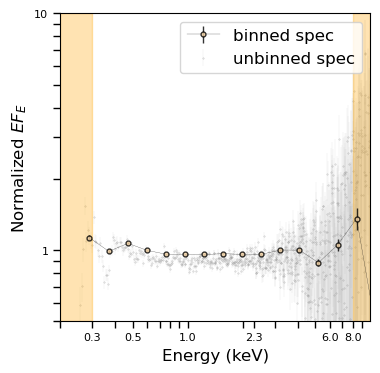

In [6]:
src_name = "./data/abspo/abspo_pi.fits"  		# source spectrum file
grp_name = "./data/abspo/abspo_grppi.fits"		# grouped source spectrum file to be created
bkg_name = "./data/abspo/abspo_bkgpi.fits"  	# background spectrum file
arf_name = "./data/abspo/abspo_arf.fits"  		# ARF file
rmf_name = "./data/abspo/abspo_rmf.fits"  		# RMF file

# create a grouped PI spectrum
with fits.open(rmf_name) as hdu:
    ebo = hdu["EBOUNDS"].data
ene_lo = ebo["E_MIN"]
ene_hi = ebo["E_MAX"]
ene_ce = (ene_lo + ene_hi) / 2
eene = np.logspace(np.log10(0.2),np.log10(ene_ce.max()),18)
eelo = eene[:-1]
eehi = eene[1:]
make_grpflg(
    src_name,   # source spectrum file
    grp_name,   # output grouped spectrum file
    method='EDGE',  # grouping spectrum by fixed edges, as specified in `eelo` and `eehi`
    rmf_fname=rmf_name,  # RMF file to be used for reading PI energy channels
    eelo=eelo,  # lower edges of the grouped energy channels
    eehi=eehi   # upper edges of the grouped energy channels
)

# make data/arf plot
fig, ax1 = plt.subplots(figsize=(4,4))
# for the grouped spectrum
make_dataarf_plot(
    src_name,
    bkg_name,
    arf_name,
    rmf_name,
    grp_name,
    normalize_at=4,	# normalize at 4 keV
    plot=True,
    ax=ax1,
    fmt="o-",ms=3.5,lw=0.20,c="k",capsize=0.,elinewidth=1.0,mec="k",mfc="#f9d7a7",alpha=0.8,zorder=1,label="binned spec"	# plotting kwargs
) # this plots EF(E), or equivalently leed in xspec; a powerlaw with photon index of 2 should look flat in this plot
# for the ungrouped spectrum
make_dataarf_plot(
    src_name,
    bkg_name,
    arf_name,
    rmf_name,
    normalize_at=4,	# normalize at 4 keV
    plot=True,
    ax=ax1,
    fmt="o",ms=0.3,lw=0.1,c="gray",alpha=0.5,zorder=-5,label="unbinned spec"
)

# below 0.3 keV: too few sources; above 8.0 keV: bkg dominated
ax1.fill_betweenx(y=[0.5,10], x1=0.2, x2=0.3, color="orange", alpha=0.3, zorder=-1) 
ax1.fill_betweenx(y=[0.5,10], x1=8.0, x2=10.0, color="orange", alpha=0.3, zorder=-1) 

ax1.legend(loc="upper right",fontsize=12)
ax1.set_xscale("log")
ax1.set_xlim(0.2,10)
x_ticks = [0.3, 0.5, 1.0, 2.3, 6.0, 8.0]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(x) for x in x_ticks])
ax1.set_xlabel("Energy (keV)",fontsize=12)
ax1.tick_params("x",which="major",
                length=10,width = 1.0,size=5,labelsize=8,pad=3)
ax1.tick_params("x",which="minor",
                length=10,width = 1.0,size=5,labelsize=8,pad=3)
ax1.set_ylim(0.5,10)
ax1.set_yscale("log")
y_ticks = [1,10]
ax1.set_yticks(y_ticks)
ax1.set_yticklabels([str(y) for y in y_ticks])
ax1.set_ylabel(r"Normalized $EF_E$",fontsize=12)
ax1.tick_params("y",which="major",
                length=10,width = 1.0,size=5,labelsize=8)
ax1.tick_params("y",which="minor",
                length=10,width = 1.0,size=5,labelsize=8)

## **e.g.3**: primary continuum (powerlaw) + soft excess (bbody)

In [2]:
# fetch some basic data (they have already been generated)
pifile_lst = []
bkgpifile_lst = []
rmffile_lst = []
arffile_lst = []
z_lst = []
nh_lst = []

for i in range(200):
    pifile = f"./data/pobb/pobb_spec/{i:05d}_pobb.pi"
    with fits.open(pifile) as hdu:
        head = hdu[1].header
    path = os.path.dirname(pifile)
    bkgpifile = os.path.join(path,head["BACKFILE"])
    rmffile = os.path.join(path,head["RESPFILE"])
    arffile = os.path.join(path,head["ANCRFILE"])
    zfile = os.path.join(path,head["ZFILE"])        # file storing redshift
    with open(zfile,"r") as f:
        z = f.readlines()
    z = float(z[0].rstrip())

    pifile_lst.append(pifile)
    bkgpifile_lst.append(bkgpifile)
    rmffile_lst.append(rmffile)
    arffile_lst.append(arffile)
    z_lst.append(z)

# run Xstack
XstackRunner(
    pifile_lst=pifile_lst,                          # PI file list
    arffile_lst=arffile_lst,                        # ARF file list
    rmffile_lst=rmffile_lst,                        # RMF file list
    z_lst=z_lst,                                    # redshift list
    bkgpifile_lst=bkgpifile_lst,                    # bkg PI file list
    srcid_lst=np.arange(200),                       # source ID list (can be arbitary)
    rspwt_method="SHP",                             # method to calculate response weighting factor for each source (recommended: SHP)
    rspproj_gamma=2.0,                              # prior photon index for projecting RSP matrix onto the output energy channel
    int_rng=(1.0,2.3),                              # if `arfscal_method`=`SHP`, choose the range to calculate flux
    sample_rmf=None,                                # the sample RMF to read input/output energy bin edge (if not specified, the first RMF in `rmffile_lst` will be used)
    sample_arf=None,                                # the sample ARF to read input/output energy bin edge (if not specified, the first RMF in `rmffile_lst` will be used)
    Nbkggrp=10,                                     # the number of background groups to calculate uncertainty of background
    ene_trc=0.2,                                    # energy below which the ARF is manually truncated (e.g., 0.2 keV for eROSITA)
    nthreads=30,                                    # number of cpus used for RMF shifting
    prefix="./data/pobb/pobb_"						# prefix for all output files
).run()

stacking: 100%|██████████| 200/200 [00:00<00:00, 322.95it/s]


Finished. Please check ./data/pobb/pobb_runXstack.log for detailed log.


([array([ 0,  0,  0, ..., 14, 18,  7], shape=(1024,))],
 [array([0.        , 0.        , 0.        , ..., 3.74165739, 4.24264069,
         2.64575131], shape=(1024,))],
 [array([ 0.        ,  0.        ,  0.        , ..., 20.504935  ,
         21.08586077, 10.83469818], shape=(1024,))],
 [array([0.        , 0.        , 0.        , ..., 0.70122689, 0.7113813 ,
         0.50925742], shape=(1024,))],
 [array([ 0.        ,  0.        ,  0.        , ..., 31.91649568,
         31.66934222, 13.56702342], shape=(1024,))],
 [array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.12254946, 0.11727072,
          0.05430803],
         [0.        , 0.        , 0.        , ..., 0.13716668, 0.14057326,

[Text(0.2, 0, '0.2'),
 Text(0.4, 0, '0.4'),
 Text(1.0, 0, '1.0'),
 Text(2.3, 0, '2.3'),
 Text(4.0, 0, '4.0'),
 Text(8.0, 0, '8.0')]

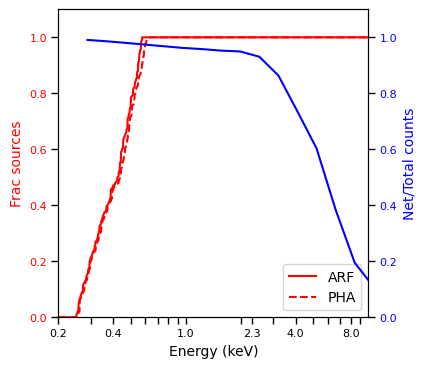

In [7]:
src_name = "./data/pobb/pobb_pi.fits"  		# source spectrum file
grp_name = "./data/pobb/pobb_grppi.fits"	# grouped source spectrum file to be created
bkg_name = "./data/pobb/pobb_bkgpi.fits"  	# background spectrum file
arf_name = "./data/pobb/pobb_arf.fits"  	# ARF file
rmf_name = "./data/pobb/pobb_rmf.fits"  	# RMF file
fene_name = "./data/pobb/pobb_fene.fits"  	# file storing the energy range of the source spectrum

fig, ax1 = plt.subplots(figsize=(4,4))
valid_energy_range_plot(fene_name,src_name,grp_name,bkg_name,rmf_name,ax=ax1)

ax1.set_xscale("log")
ax1.set_xlim(0.2,10)
x_ticks = [0.2, 0.4, 1.0, 2.3, 4.0, 8.0]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(x) for x in x_ticks])

/data/chsj/software/installed/miniforge3/envs/henv/lib/python3.13/site-packages/Xstack/utils/rsp.py:1007: RuntimeWarning: invalid value encountered in divide
  grpspecresp.append((tmpspecresp * tmpwt / tmpwt.sum()).sum())
/data/chsj/software/installed/miniforge3/envs/henv/lib/python3.13/site-packages/Xstack/utils/rsp.py:1025: RuntimeWarning: invalid value encountered in divide
  grpspecresp.append((tmpspecresp * tmpwt / tmpwt.sum()).sum())


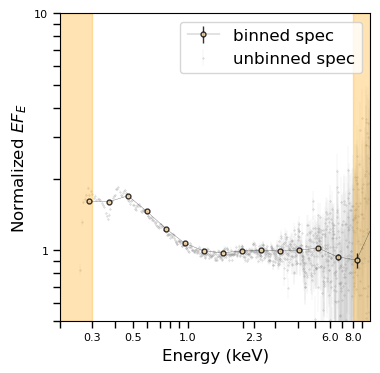

In [8]:
src_name = "./data/pobb/pobb_pi.fits"  		# source spectrum file
grp_name = "./data/pobb/pobb_grppi.fits"	# grouped source spectrum file to be created
bkg_name = "./data/pobb/pobb_bkgpi.fits"  	# background spectrum file
arf_name = "./data/pobb/pobb_arf.fits"  	# ARF file
rmf_name = "./data/pobb/pobb_rmf.fits"  	# RMF file

# create a grouped PI spectrum
with fits.open(rmf_name) as hdu:
    ebo = hdu["EBOUNDS"].data
ene_lo = ebo["E_MIN"]
ene_hi = ebo["E_MAX"]
ene_ce = (ene_lo + ene_hi) / 2
eene = np.logspace(np.log10(0.2),np.log10(ene_ce.max()),18)
eelo = eene[:-1]
eehi = eene[1:]
make_grpflg(
    src_name,   # source spectrum file
    grp_name,   # output grouped spectrum file
    method='EDGE',  # grouping spectrum by fixed edges, as specified in `eelo` and `eehi`
    rmf_fname=rmf_name,  # RMF file to be used for reading PI energy channels
    eelo=eelo,  # lower edges of the grouped energy channels
    eehi=eehi   # upper edges of the grouped energy channels
)

# make data/arf plot
fig, ax1 = plt.subplots(figsize=(4,4))
# for the grouped spectrum
make_dataarf_plot(
    src_name,
    bkg_name,
    arf_name,
    rmf_name,
    grp_name,
    normalize_at=4,	# normalize at 4 keV
    plot=True,
    ax=ax1,
    fmt="o-",ms=3.5,lw=0.20,c="k",capsize=0.,elinewidth=1.0,mec="k",mfc="#f9d7a7",alpha=0.8,zorder=1,label="binned spec"	# plotting kwargs
) # this plots EF(E), or equivalently leed in xspec; a powerlaw with photon index of 2 should look flat in this plot
# for the ungrouped spectrum
make_dataarf_plot(
    src_name,
    bkg_name,
    arf_name,
    rmf_name,
    normalize_at=4,	# normalize at 4 keV
    plot=True,
    ax=ax1,
    fmt="o",ms=0.3,lw=0.1,c="gray",alpha=0.5,zorder=-5,label="unbinned spec"
)

# below 0.3 keV: too few sources; above 8.0 keV: bkg dominated
ax1.fill_betweenx(y=[0.5,10], x1=0.2, x2=0.3, color="orange", alpha=0.3, zorder=-1) 
ax1.fill_betweenx(y=[0.5,10], x1=8.0, x2=10.0, color="orange", alpha=0.3, zorder=-1) 

ax1.legend(loc="upper right",fontsize=12)
ax1.set_xscale("log")
ax1.set_xlim(0.2,10)
x_ticks = [0.3, 0.5, 1.0, 2.3, 6.0, 8.0]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(x) for x in x_ticks])
ax1.set_xlabel("Energy (keV)",fontsize=12)
ax1.tick_params("x",which="major",
                length=10,width = 1.0,size=5,labelsize=8,pad=3)
ax1.tick_params("x",which="minor",
                length=10,width = 1.0,size=5,labelsize=8,pad=3)
ax1.set_ylim(0.5,10)
ax1.set_yscale("log")
y_ticks = [1,10]
ax1.set_yticks(y_ticks)
ax1.set_yticklabels([str(y) for y in y_ticks])
ax1.set_ylabel(r"Normalized $EF_E$",fontsize=12)
ax1.tick_params("y",which="major",
                length=10,width = 1.0,size=5,labelsize=8)
ax1.tick_params("y",which="minor",
                length=10,width = 1.0,size=5,labelsize=8)

## **e.g.4**: absorbed primary continuum (powerlaw) + soft excess (bbody)

In [6]:
# fetch some basic data (they have already been generated)
pifile_lst = []
bkgpifile_lst = []
rmffile_lst = []
arffile_lst = []
z_lst = []
nh_lst = []

for i in range(200):
    pifile = f"./data/abspobb/abspobb_spec/{i:05d}_abspobb.pi"
    with fits.open(pifile) as hdu:
        head = hdu[1].header
    path = os.path.dirname(pifile)
    bkgpifile = os.path.join(path,head["BACKFILE"])
    rmffile = os.path.join(path,head["RESPFILE"])
    arffile = os.path.join(path,head["ANCRFILE"])
    zfile = os.path.join(path,head["ZFILE"])        # file storing redshift
    nhfile = os.path.join(path,head["NHFILE"])        # file storing NH
    with open(zfile,"r") as f:
        z = f.readlines()
    z = float(z[0].rstrip())
    with open(nhfile,"r") as f:
        nh = f.readlines()
    nh = float(nh[0].rstrip())

    pifile_lst.append(pifile)
    bkgpifile_lst.append(bkgpifile)
    rmffile_lst.append(rmffile)
    arffile_lst.append(arffile)
    z_lst.append(z)
    nh_lst.append(nh)

# run Xstack
XstackRunner(
    pifile_lst=pifile_lst,                          # PI file list
    arffile_lst=arffile_lst,                        # ARF file list
    rmffile_lst=rmffile_lst,                        # RMF file list
    z_lst=z_lst,                                    # redshift list
    bkgpifile_lst=bkgpifile_lst,                    # bkg PI file list
    nh_lst=nh_lst,                                  # nh list
    srcid_lst=np.arange(200),                       # source ID list (can be arbitary)
    rspwt_method="SHP",                             # method to calculate response weighting factor for each source (recommended: SHP)
    rspproj_gamma=2.0,                              # prior photon index for projecting RSP matrix onto the output energy channel
    int_rng=(1.0,2.3),                              # if `arfscal_method`=`SHP`, choose the range to calculate flux
    sample_rmf=None,                                # the sample RMF to read input/output energy bin edge (if not specified, the first RMF in `rmffile_lst` will be used)
    sample_arf=None,                                # the sample ARF to read input/output energy bin edge (if not specified, the first RMF in `rmffile_lst` will be used)
    nh_file=default_nh_file,                 		# the Galactic absorption profile (absorption factor vs. energy)
    Nbkggrp=10,                                     # the number of background groups to calculate uncertainty of background
    ene_trc=0.2,                                    # energy below which the ARF is manually truncated (e.g., 0.2 keV for eROSITA)
    nthreads=30,                                    # number of cpus used for RMF shifting
    prefix="./data/abspobb/abspobb_"				# prefix for all output files
).run()

stacking: 100%|██████████| 200/200 [00:00<00:00, 249.19it/s]


Finished. Please check ./data/abspobb/abspobb_runXstack.log for detailed log.


([array([ 0,  0,  0, ..., 14, 18,  9], shape=(1024,))],
 [array([0.        , 0.        , 0.        , ..., 3.74165739, 4.24264069,
         3.        ], shape=(1024,))],
 [array([ 0.        ,  0.        ,  0.        , ..., 20.08257604,
         21.07327275, 10.67869305], shape=(1024,))],
 [array([0.        , 0.        , 0.        , ..., 0.69299624, 0.71017044,
         0.5064329 ], shape=(1024,))],
 [array([ 0.        ,  0.        ,  0.        , ..., 31.3738663 ,
         31.12902859, 13.2156064 ], shape=(1024,))],
 [array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [1.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.12285948, 0.11751483,
          0.05478746],
         [0.        , 0.        , 0.        , ..., 0.13753753, 0.14096234,

[Text(0.2, 0, '0.2'),
 Text(0.4, 0, '0.4'),
 Text(1.0, 0, '1.0'),
 Text(2.3, 0, '2.3'),
 Text(4.0, 0, '4.0'),
 Text(8.0, 0, '8.0')]

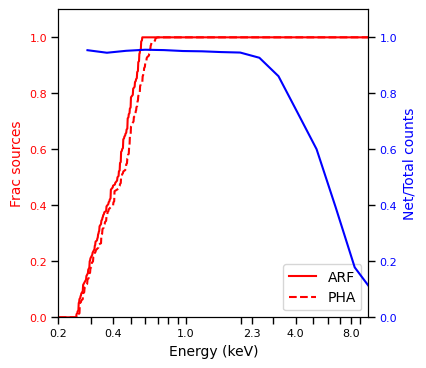

In [9]:
src_name = "./data/abspobb/abspobb_pi.fits"  		# source spectrum file
grp_name = "./data/abspobb/abspobb_grppi.fits"		# grouped source spectrum file to be created
bkg_name = "./data/abspobb/abspobb_bkgpi.fits"  	# background spectrum file
arf_name = "./data/abspobb/abspobb_arf.fits"  		# ARF file
rmf_name = "./data/abspobb/abspobb_rmf.fits"  		# RMF file
fene_name = "./data/abspobb/abspobb_fene.fits"  	# file storing the energy range of the source spectrum

fig, ax1 = plt.subplots(figsize=(4,4))
valid_energy_range_plot(fene_name,src_name,grp_name,bkg_name,rmf_name,ax=ax1)

ax1.set_xscale("log")
ax1.set_xlim(0.2,10)
x_ticks = [0.2, 0.4, 1.0, 2.3, 4.0, 8.0]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(x) for x in x_ticks])

/data/chsj/software/installed/miniforge3/envs/henv/lib/python3.13/site-packages/Xstack/utils/rsp.py:1007: RuntimeWarning: invalid value encountered in divide
  grpspecresp.append((tmpspecresp * tmpwt / tmpwt.sum()).sum())
/data/chsj/software/installed/miniforge3/envs/henv/lib/python3.13/site-packages/Xstack/utils/rsp.py:1025: RuntimeWarning: invalid value encountered in divide
  grpspecresp.append((tmpspecresp * tmpwt / tmpwt.sum()).sum())


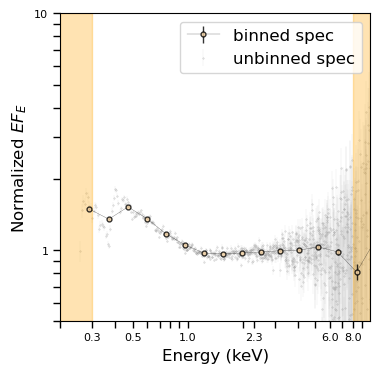

In [10]:
src_name = "./data/abspobb/abspobb_pi.fits"  		# source spectrum file
grp_name = "./data/abspobb/abspobb_grppi.fits"		# grouped source spectrum file to be created
bkg_name = "./data/abspobb/abspobb_bkgpi.fits"  	# background spectrum file
arf_name = "./data/abspobb/abspobb_arf.fits"  		# ARF file
rmf_name = "./data/abspobb/abspobb_rmf.fits"  		# RMF file

# create a grouped PI spectrum
with fits.open(rmf_name) as hdu:
    ebo = hdu["EBOUNDS"].data
ene_lo = ebo["E_MIN"]
ene_hi = ebo["E_MAX"]
ene_ce = (ene_lo + ene_hi) / 2
eene = np.logspace(np.log10(0.2),np.log10(ene_ce.max()),18)
eelo = eene[:-1]
eehi = eene[1:]
make_grpflg(
    src_name,   # source spectrum file
    grp_name,   # output grouped spectrum file
    method='EDGE',  # grouping spectrum by fixed edges, as specified in `eelo` and `eehi`
    rmf_fname=rmf_name,  # RMF file to be used for reading PI energy channels
    eelo=eelo,  # lower edges of the grouped energy channels
    eehi=eehi   # upper edges of the grouped energy channels
)

# make data/arf plot
fig, ax1 = plt.subplots(figsize=(4,4))
# for the grouped spectrum
make_dataarf_plot(
    src_name,
    bkg_name,
    arf_name,
    rmf_name,
    grp_name,
    normalize_at=4,	# normalize at 4 keV
    plot=True,
    ax=ax1,
    fmt="o-",ms=3.5,lw=0.20,c="k",capsize=0.,elinewidth=1.0,mec="k",mfc="#f9d7a7",alpha=0.8,zorder=1,label="binned spec"	# plotting kwargs
) # this plots EF(E), or equivalently leed in xspec; a powerlaw with photon index of 2 should look flat in this plot
# for the ungrouped spectrum
make_dataarf_plot(
    src_name,
    bkg_name,
    arf_name,
    rmf_name,
    normalize_at=4,	# normalize at 4 keV
    plot=True,
    ax=ax1,
    fmt="o",ms=0.3,lw=0.1,c="gray",alpha=0.5,zorder=-5,label="unbinned spec"
)

# below 0.3 keV: too few sources; above 8.0 keV: bkg dominated
ax1.fill_betweenx(y=[0.5,10], x1=0.2, x2=0.3, color="orange", alpha=0.3, zorder=-1) 
ax1.fill_betweenx(y=[0.5,10], x1=8.0, x2=10.0, color="orange", alpha=0.3, zorder=-1) 

ax1.legend(loc="upper right",fontsize=12)
ax1.set_xscale("log")
ax1.set_xlim(0.2,10)
x_ticks = [0.3, 0.5, 1.0, 2.3, 6.0, 8.0]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(x) for x in x_ticks])
ax1.set_xlabel("Energy (keV)",fontsize=12)
ax1.tick_params("x",which="major",
                length=10,width = 1.0,size=5,labelsize=8,pad=3)
ax1.tick_params("x",which="minor",
                length=10,width = 1.0,size=5,labelsize=8,pad=3)
ax1.set_ylim(0.5,10)
ax1.set_yscale("log")
y_ticks = [1,10]
ax1.set_yticks(y_ticks)
ax1.set_yticklabels([str(y) for y in y_ticks])
ax1.set_ylabel(r"Normalized $EF_E$",fontsize=12)
ax1.tick_params("y",which="major",
                length=10,width = 1.0,size=5,labelsize=8)
ax1.tick_params("y",which="minor",
                length=10,width = 1.0,size=5,labelsize=8)

# **3. (optional) Generate some fake spectra**

## single powerlaws

In [24]:
# subprocess.run(["python", "./generate_scripts/generate_po.py"],stdin=devnull) # gives wrong HEADER
!python ./generate_scripts/generate_po.py

100%|█████████████████████████████████████████| 200/200 [00:04<00:00, 44.01it/s]


## single absorbed powerlaw

In [7]:
!python ./generate_scripts/generate_abspo.py

100%|█████████████████████████████████████████| 200/200 [00:05<00:00, 34.30it/s]


## primary continuum (powerlaw) + soft excess (bbody)

In [17]:
!python ./generate_scripts/generate_pobb.py

100%|█████████████████████████████████████████| 200/200 [00:04<00:00, 46.13it/s]


## absorbed primary continuum (powerlaw) + soft excess (bbody)

In [20]:
!python ./generate_scripts/generate_abspobb.py

100%|█████████████████████████████████████████| 200/200 [00:07<00:00, 26.48it/s]
